In [2]:
import osmnx as ox
import pandas as pd
from shapely.geometry import Point
from pyproj import Transformer

# 1. 강남역 근처 도보 도로망 받기 (오늘 이미 확인했던 것과 동일)
gangnam = (37.4979, 127.0276)

In [3]:
G = ox.graph_from_point(gangnam, dist=500, network_type="walk")

# 2. 간선 하나 고르기 (첫 번째 간선)
u, v, data = list(G.edges(data=True))[0]
length_m = data["length"]
geometry = data["geometry"]  # LineString, 위경도(WGS84) 좌표
print("고른 간선:", data.get("name", "(이름 없음)"))
print("원래 거리(length):", round(length_m, 1), "m")

# 3. 이 간선 주변 가로등 개수 세기
#    거리 계산은 미터 단위(EPSG:5179)에서 해야 함 — 위경도로 하면 안 됨
to_5179 = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)

# 간선(geometry)을 EPSG:5179로 투영
edge_coords_5179 = [to_5179.transform(lon, lat) for lon, lat in geometry.coords]
from shapely.geometry import LineString
edge_line_5179 = LineString(edge_coords_5179)

# 가로등 데이터 불러오기 (정제된 통합 파일)
lights = pd.read_csv(
    "/Users/user/Desktop/runstop/정제/서울특별시_가로등위치정보_통합.csv",
    encoding="utf-8-sig",
)

BUFFER_M = 30  # 간선 주변 30m 이내 가로등만 카운트
count = 0
for lat, lon in zip(lights["위도"], lights["경도"]):
    x, y = to_5179.transform(lon, lat)
    if edge_line_5179.distance(Point(x, y)) <= BUFFER_M:
        count += 1

print(f"주변 {BUFFER_M}m 이내 가로등 개수:", count)

# 4. 가중치 계산 (가로등 하나당 2m씩 "할인" — 나중에 공식은 다듬으면 됨)
DISCOUNT_PER_LIGHT = 2.0
weight = max(1.0, length_m - count * DISCOUNT_PER_LIGHT)

print("\n=== 비교 ===")
print("원래 거리(length):", round(length_m, 1), "m")
print("새 가중치(weight): ", round(weight, 1), "m  (가로등", count, "개 반영)")


from pyproj import Transformer

to_5179 = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)
cx, cy = to_5179.transform(gangnam[1], gangnam[0])  # 중심점(강남역) 좌표

for radius in [100, 300, 500, 1000, 2000]:
    count = 0
    for lat, lon in zip(lights["위도"], lights["경도"]):
        x, y = to_5179.transform(lon, lat)
        if ((x - cx)**2 + (y - cy)**2) ** 0.5 <= radius:
            count += 1
    print(f"반경 {radius}m 이내 가로등: {count}개")

# 참고용: 서초구 데이터가 이 CSV에 실제로 몇 개나 있는지도 확인
print("\n전체 데이터 중 서초구 행 개수:", (lights["구"] == "서초구").sum())

고른 간선: 서초대로
원래 거리(length): 18.2 m
주변 30m 이내 가로등 개수: 0

=== 비교 ===
원래 거리(length): 18.2 m
새 가중치(weight):  18.2 m  (가로등 0 개 반영)
반경 100m 이내 가로등: 0개
반경 300m 이내 가로등: 0개
반경 500m 이내 가로등: 0개
반경 1000m 이내 가로등: 0개
반경 2000m 이내 가로등: 18개

전체 데이터 중 서초구 행 개수: 774


In [4]:
from pyproj import Transformer

to_5179 = Transformer.from_crs("EPSG:4326", "EPSG:5179", always_xy=True)
cx, cy = to_5179.transform(gangnam[1], gangnam[0])  # 중심점(강남역) 좌표

for radius in [100, 300, 500, 1000, 2000]:
    count = 0
    for lat, lon in zip(lights["위도"], lights["경도"]):
        x, y = to_5179.transform(lon, lat)
        if ((x - cx)**2 + (y - cy)**2) ** 0.5 <= radius:
            count += 1
    print(f"반경 {radius}m 이내 가로등: {count}개")

# 참고용: 서초구 데이터가 이 CSV에 실제로 몇 개나 있는지도 확인
print("\n전체 데이터 중 서초구 행 개수:", (lights["구"] == "서초구").sum())

반경 100m 이내 가로등: 0개
반경 300m 이내 가로등: 0개
반경 500m 이내 가로등: 0개
반경 1000m 이내 가로등: 0개
반경 2000m 이내 가로등: 18개

전체 데이터 중 서초구 행 개수: 774


In [5]:
mapo_lights = lights[lights["구"] == "마포구"]
print("마포구 가로등 행 개수:", len(mapo_lights))
print("위도 범위:", mapo_lights["위도"].min(), "~", mapo_lights["위도"].max())
print("경도 범위:", mapo_lights["경도"].min(), "~", mapo_lights["경도"].max())

center_lat = mapo_lights["위도"].mean()
center_lon = mapo_lights["경도"].mean()
print("마포구 가로등 평균 중심 좌표:", center_lat, center_lon)

# 이 실제 중심점 기준으로 다시 반경 테스트
mx, my = to_5179.transform(center_lon, center_lat)
for radius in [100, 300, 500, 1000]:
    count = 0
    for lat, lon in zip(lights["위도"], lights["경도"]):
        x, y = to_5179.transform(lon, lat)
        if ((x - mx)**2 + (y - my)**2) ** 0.5 <= radius:
            count += 1
    print(f"반경 {radius}m 이내 가로등: {count}개")

마포구 가로등 행 개수: 2096
위도 범위: 37.527176 ~ 37.580182
경도 범위: 126.859895 ~ 126.949139
마포구 가로등 평균 중심 좌표: 37.55536685066794 126.90197230725191
반경 100m 이내 가로등: 0개
반경 300m 이내 가로등: 0개
반경 500m 이내 가로등: 74개
반경 1000m 이내 가로등: 436개


In [6]:
mapo_center = (center_lat, center_lon)
G_mapo = ox.graph_from_point(mapo_center, dist=500, network_type="walk")

u, v, data = list(G_mapo.edges(data=True))[0]
length_m = data["length"]

# geometry가 없으면(직선 구간) 두 끝점 좌표로 직접 만든다
if "geometry" in data:
    coords = list(data["geometry"].coords)  # [(lon, lat), ...]
else:
    coords = [
        (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
        (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
    ]

print("고른 간선:", data.get("name", "(이름 없음)"), "- 거리:", round(length_m, 1), "m")

edge_coords_5179 = [to_5179.transform(lon, lat) for lon, lat in coords]
edge_line_5179 = LineString(edge_coords_5179)

BUFFER_M = 150
count = 0
for lat, lon in zip(lights["위도"], lights["경도"]):
    x, y = to_5179.transform(lon, lat)
    if edge_line_5179.distance(Point(x, y)) <= BUFFER_M:
        count += 1

DISCOUNT_PER_LIGHT = 2.0
weight = max(1.0, length_m - count * DISCOUNT_PER_LIGHT)

print("주변", BUFFER_M, "m 이내 가로등:", count, "개")
print("원래 거리:", round(length_m, 1), "m  ->  새 가중치:", round(weight, 1), "m")

고른 간선: 희우정로 - 거리: 44.5 m
주변 150 m 이내 가로등: 0 개
원래 거리: 44.5 m  ->  새 가중치: 44.5 m


In [7]:
nonzero = 0
max_count = 0
total_checked = 0
best_edge = None

for u, v, data in G_mapo.edges(data=True):
    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
            (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
        ]
    edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

    count = 0
    for lat, lon in zip(lights["위도"], lights["경도"]):
        x, y = to_5179.transform(lon, lat)
        if edge_line_5179.distance(Point(x, y)) <= 150:
            count += 1

    total_checked += 1
    if count > 0:
        nonzero += 1
    if count > max_count:
        max_count = count
        best_edge = data.get("name", "(이름없음)")

print(f"전체 간선 {total_checked}개 중 가로등 1개 이상: {nonzero}개")
print(f"가장 많은 간선: {best_edge} - 가로등 {max_count}개")

전체 간선 1332개 중 가로등 1개 이상: 162개
가장 많은 간선: 동교로1길 - 가로등 74개


In [8]:
for u, v, data in G_mapo.edges(data=True):
    if data.get("name") == "동교로1길":
        length_m = data["length"]

        if "geometry" in data:
            coords = list(data["geometry"].coords)
        else:
            coords = [
                (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
                (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
            ]
        edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

        count = 0
        for lat, lon in zip(lights["위도"], lights["경도"]):
            x, y = to_5179.transform(lon, lat)
            if edge_line_5179.distance(Point(x, y)) <= 150:
                count += 1

        weight = max(1.0, length_m - count * 2.0)
        print("간선: 동교로1길")
        print("원래 거리:", round(length_m, 1), "m")
        print("가로등:", count, "개")
        print("새 가중치:", round(weight, 1), "m")
        break
    

간선: 동교로1길
원래 거리: 185.5 m
가로등: 74 개
새 가중치: 37.5 m


In [9]:
BUFFER_M = 150
DISCOUNT_PER_LIGHT = 2.0

light_count_total = 0
weighted_count = 0

for u, v, key, data in G_mapo.edges(keys=True, data=True):
    length_m = data["length"]

    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
            (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
        ]
    edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

    count = 0
    for lat, lon in zip(lights["위도"], lights["경도"]):
        x, y = to_5179.transform(lon, lat)
        if edge_line_5179.distance(Point(x, y)) <= BUFFER_M:
            count += 1

    weight = max(1.0, length_m - count * DISCOUNT_PER_LIGHT)

    # 이 간선에 가중치를 직접 저장 (나중에 경로탐색에서 바로 사용 가능)
    G_mapo[u][v][key]["light_count"] = count
    G_mapo[u][v][key]["weight"] = weight

    light_count_total += count
    if count > 0:
        weighted_count += 1

print("전체 간선 수:", G_mapo.number_of_edges())
print("가로등 반영된 간선 수:", weighted_count)
print("전체 가로등 카운트 합계(중복 포함):", light_count_total)

전체 간선 수: 1332
가로등 반영된 간선 수: 162
전체 가로등 카운트 합계(중복 포함): 3622


In [10]:
import networkx as nx

nodes = list(G_mapo.nodes)
origin = nodes[0]
destination = nodes[-1]

# 1) 그냥 최단거리 기준 경로
path_shortest = nx.shortest_path(G_mapo, origin, destination, weight="length")
# 2) 우리 가중치(가로등 반영) 기준 경로
path_weighted = nx.shortest_path(G_mapo, origin, destination, weight="weight")

def path_length(path, attr):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        # 병렬 간선 있을 수 있어서 최소값으로
        edge_data = min(G_mapo[u][v].values(), key=lambda d: d[attr])
        total += edge_data[attr]
    return total

def path_lights(path):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = min(G_mapo[u][v].values(), key=lambda d: d["weight"])
        total += edge_data.get("light_count", 0)
    return total

print("=== 최단거리 기준 경로 ===")
print("노드 수:", len(path_shortest))
print("실제 거리 합:", round(path_length(path_shortest, "length"), 1), "m")
print("지나는 가로등 합:", path_lights(path_shortest))

print("\n=== 가로등 반영 가중치 기준 경로 ===")
print("노드 수:", len(path_weighted))
print("실제 거리 합:", round(path_length(path_weighted, "length"), 1), "m")
print("지나는 가로등 합:", path_lights(path_weighted))

print("\n두 경로가 같은가?", path_shortest == path_weighted)

=== 최단거리 기준 경로 ===
노드 수: 9
실제 거리 합: 299.2 m
지나는 가로등 합: 0

=== 가로등 반영 가중치 기준 경로 ===
노드 수: 9
실제 거리 합: 299.2 m
지나는 가로등 합: 0

두 경로가 같은가? True


In [11]:
# 실제로 지리적으로 멀리 떨어진 두 지점 고르기 (그래프의 서쪽 끝, 동쪽 끝)
nodes_by_x = sorted(G_mapo.nodes, key=lambda n: G_mapo.nodes[n]["x"])
origin = nodes_by_x[0]        # 가장 서쪽
destination = nodes_by_x[-1]  # 가장 동쪽

# 할인폭을 2 -> 30으로 크게 키운 가중치를 새로 계산
DISCOUNT_PER_LIGHT_STRONG = 30.0
for u, v, key, data in G_mapo.edges(keys=True, data=True):
    count = data.get("light_count", 0)
    data["weight_strong"] = max(1.0, data["length"] - count * DISCOUNT_PER_LIGHT_STRONG)

path_shortest = nx.shortest_path(G_mapo, origin, destination, weight="length")
path_weighted = nx.shortest_path(G_mapo, origin, destination, weight="weight_strong")

print("두 경로가 같은가?", path_shortest == path_weighted)
print("최단거리 경로 길이:", round(path_length(path_shortest, "length"), 1), "m  / 가로등:", path_lights(path_shortest))
print("가중치 경로 길이:  ", round(path_length(path_weighted, "length"), 1), "m  / 가로등:", path_lights(path_weighted))

두 경로가 같은가? False
최단거리 경로 길이: 1420.1 m  / 가로등: 48
가중치 경로 길이:   2032.5 m  / 가로등: 482


In [12]:
import sys
sys.path.insert(0, "/Users/user/Desktop/runstop/경사도")
from query_elevation import slope_percent

# 화장실, 편의점 데이터 추가로 불러오기 (가로등 lights는 이미 있음)
toilets = pd.read_csv(
    "/Users/user/Desktop/runstop/정제/공중화장실정보_서울특별시_좌표포함.csv",
    encoding="utf-8-sig",
).dropna(subset=["위도", "경도"])

stores = pd.read_csv(
    "/Users/user/Desktop/runstop/정제/safemap_편의점_서울_정제.csv",
    encoding="utf-8-sig",
)

def count_nearby(edge_line_5179, df, lat_col, lon_col, buffer_m):
    count = 0
    for lat, lon in zip(df[lat_col], df[lon_col]):
        x, y = to_5179.transform(lon, lat)
        if edge_line_5179.distance(Point(x, y)) <= buffer_m:
            count += 1
    return count

for u, v, data in G_mapo.edges(data=True):
    if data.get("name") == "동교로1길":
        length_m = data["length"]
        if "geometry" in data:
            coords = list(data["geometry"].coords)
        else:
            coords = [
                (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
                (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
            ]
        edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

        light_cnt = count_nearby(edge_line_5179, lights, "위도", "경도", 150)
        toilet_cnt = count_nearby(edge_line_5179, toilets, "위도", "경도", 150)
        store_cnt = count_nearby(edge_line_5179, stores, "위도_wgs84", "경도_wgs84", 150)

        lat1, lon1 = G_mapo.nodes[u]["y"], G_mapo.nodes[u]["x"]
        lat2, lon2 = G_mapo.nodes[v]["y"], G_mapo.nodes[v]["x"]
        slope = slope_percent(lat1, lon1, lat2, lon2) or 0.0

        print("간선: 동교로1길 - 거리:", round(length_m, 1), "m")
        print(f"가로등 {light_cnt}개 / 화장실 {toilet_cnt}개 / 편의점 {store_cnt}개 / 경사 {slope:.2f}%")

        # 종합 가중치: 시설(가로등/화장실/편의점) 많으면 할인, 경사 있으면 할증
        DISCOUNT = 2.0        # 시설 1개당 2m 할인
        SLOPE_PENALTY = 5.0   # 경사 1%마다 5m 할증
        bonus = (light_cnt + toilet_cnt + store_cnt) * DISCOUNT
        penalty = slope * SLOPE_PENALTY
        weight = max(1.0, length_m - bonus + penalty)

        print("종합 가중치:", round(weight, 1), "m")
        break
import sys
sys.path.insert(0, "/Users/user/Desktop/runstop/경사도")
from query_elevation import slope_percent

# 화장실, 편의점 데이터 추가로 불러오기 (가로등 lights는 이미 있음)
toilets = pd.read_csv(
    "/Users/user/Desktop/runstop/정제/공중화장실정보_서울특별시_좌표포함.csv",
    encoding="utf-8-sig",
).dropna(subset=["위도", "경도"])

stores = pd.read_csv(
    "/Users/user/Desktop/runstop/정제/safemap_편의점_서울_정제.csv",
    encoding="utf-8-sig",
)

def count_nearby(edge_line_5179, df, lat_col, lon_col, buffer_m):
    count = 0
    for lat, lon in zip(df[lat_col], df[lon_col]):
        x, y = to_5179.transform(lon, lat)
        if edge_line_5179.distance(Point(x, y)) <= buffer_m:
            count += 1
    return count

for u, v, data in G_mapo.edges(data=True):
    if data.get("name") == "동교로1길":
        length_m = data["length"]
        if "geometry" in data:
            coords = list(data["geometry"].coords)
        else:
            coords = [
                (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
                (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
            ]
        edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

        light_cnt = count_nearby(edge_line_5179, lights, "위도", "경도", 150)
        toilet_cnt = count_nearby(edge_line_5179, toilets, "위도", "경도", 150)
        store_cnt = count_nearby(edge_line_5179, stores, "위도_wgs84", "경도_wgs84", 150)

        lat1, lon1 = G_mapo.nodes[u]["y"], G_mapo.nodes[u]["x"]
        lat2, lon2 = G_mapo.nodes[v]["y"], G_mapo.nodes[v]["x"]
        slope = slope_percent(lat1, lon1, lat2, lon2) or 0.0

        print("간선: 동교로1길 - 거리:", round(length_m, 1), "m")
        print(f"가로등 {light_cnt}개 / 화장실 {toilet_cnt}개 / 편의점 {store_cnt}개 / 경사 {slope:.2f}%")

        # 종합 가중치: 시설(가로등/화장실/편의점) 많으면 할인, 경사 있으면 할증
        DISCOUNT = 2.0        # 시설 1개당 2m 할인
        SLOPE_PENALTY = 5.0   # 경사 1%마다 5m 할증
        bonus = (light_cnt + toilet_cnt + store_cnt) * DISCOUNT
        penalty = slope * SLOPE_PENALTY
        weight = max(1.0, length_m - bonus + penalty)

        print("종합 가중치:", round(weight, 1), "m")
        break

간선: 동교로1길 - 거리: 185.5 m
가로등 74개 / 화장실 1개 / 편의점 3개 / 경사 0.20%
종합 가중치: 30.5 m
간선: 동교로1길 - 거리: 185.5 m
가로등 74개 / 화장실 1개 / 편의점 3개 / 경사 0.20%
종합 가중치: 30.5 m


In [13]:
DISCOUNT = 2.0
SLOPE_PENALTY = 5.0

for u, v, key, data in G_mapo.edges(keys=True, data=True):
    length_m = data["length"]
    light_cnt = data.get("light_count", 0)  # 아까 계산해둔 값 재사용

    if "geometry" in data:
        coords = list(data["geometry"].coords)
    else:
        coords = [
            (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
            (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
        ]
    edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

    toilet_cnt = count_nearby(edge_line_5179, toilets, "위도", "경도", 150)
    store_cnt = count_nearby(edge_line_5179, stores, "위도_wgs84", "경도_wgs84", 150)

    lat1, lon1 = G_mapo.nodes[u]["y"], G_mapo.nodes[u]["x"]
    lat2, lon2 = G_mapo.nodes[v]["y"], G_mapo.nodes[v]["x"]
    slope = slope_percent(lat1, lon1, lat2, lon2) or 0.0

    bonus = (light_cnt + toilet_cnt + store_cnt) * DISCOUNT
    penalty = slope * SLOPE_PENALTY
    weight_full = max(1.0, length_m - bonus + penalty)

    data["toilet_count"] = toilet_cnt
    data["store_count"] = store_cnt
    data["slope_pct"] = slope
    data["weight_full"] = weight_full

print("전체 간선에 종합 가중치 적용 완료")

전체 간선에 종합 가중치 적용 완료


In [14]:
path_shortest = nx.shortest_path(G_mapo, origin, destination, weight="length")
path_full = nx.shortest_path(G_mapo, origin, destination, weight="weight_full")

def path_facility_sum(path, attr):
    total = 0
    for u, v in zip(path[:-1], path[1:]):
        edge_data = min(G_mapo[u][v].values(), key=lambda d: d["weight_full"])
        total += edge_data.get(attr, 0)
    return total

print("두 경로가 같은가?", path_shortest == path_full)
print("최단거리 경로 - 거리:", round(path_length(path_shortest, "length"), 1), "m")
print("  가로등:", path_facility_sum(path_shortest, "light_count"),
      "화장실:", path_facility_sum(path_shortest, "toilet_count"),
      "편의점:", path_facility_sum(path_shortest, "store_count"))

print("종합가중치 경로 - 거리:", round(path_length(path_full, "length"), 1), "m")
print("  가로등:", path_facility_sum(path_full, "light_count"),
      "화장실:", path_facility_sum(path_full, "toilet_count"),
      "편의점:", path_facility_sum(path_full, "store_count"))

두 경로가 같은가? False
최단거리 경로 - 거리: 1420.1 m
  가로등: 48 화장실: 62 편의점: 146
종합가중치 경로 - 거리: 1739.2 m
  가로등: 439 화장실: 66 편의점: 149


In [15]:
tags = {
    "leisure": "park",
    "landuse": ["grass", "forest", "meadow"],
    "natural": ["water", "wood"],
    "waterway": True,  # 하천/개울 선(line) 데이터
}

green_water = ox.features_from_point(mapo_center, tags=tags, dist=500)

print("받아온 개수:", len(green_water))
print("\n도형 타입별 개수:")
print(green_water.geom_type.value_counts())

print("\n샘플 몇 개:")
print(green_water[["geometry"]].head(5))

받아온 개수: 7

도형 타입별 개수:
Polygon    7
Name: count, dtype: int64

샘플 몇 개:
                                                             geometry
element  id                                                          
relation 152336     POLYGON ((126.665 37.77061, 126.67443 37.77296...
way      300403710  POLYGON ((126.90302 37.55143, 126.90293 37.551...
         300782783  POLYGON ((126.90585 37.55576, 126.90616 37.555...
         330666503  POLYGON ((126.90176 37.55109, 126.90138 37.551...
         342450216  POLYGON ((126.9009 37.55282, 126.90071 37.5526...


In [16]:
for idx, row in green_water.iterrows():
    bounds = row.geometry.bounds  # (minx, miny, maxx, maxy)
    centroid = row.geometry.centroid
    print(idx, "- 중심점:", round(centroid.y, 4), round(centroid.x, 4), "- bbox:", [round(b,4) for b in bounds])

('relation', 152336) - 중심점: 37.6217 126.8099 - bbox: [126.6563, 37.5062, 127.0916, 37.7731]
('way', 300403710) - 중심점: 37.5512 126.9033 - bbox: [126.9029, 37.5505, 126.9039, 37.5517]
('way', 300782783) - 중심점: 37.5556 126.9061 - bbox: [126.9059, 37.5554, 126.9063, 37.5558]
('way', 330666503) - 중심점: 37.551 126.9011 - bbox: [126.8938, 37.5444, 126.9098, 37.5563]
('way', 342450216) - 중심점: 37.5531 126.9004 - bbox: [126.8999, 37.5527, 126.9009, 37.5535]
('way', 345649616) - 중심점: 37.5512 126.9023 - bbox: [126.9018, 37.5508, 126.9028, 37.5515]
('way', 583278627) - 중심점: 37.5535 126.8972 - bbox: [126.8968, 37.5532, 126.8976, 37.5538]


In [17]:
GREEN_BUFFER_M = 50  # 강/공원 경계에서 50m 이내면 "인접"으로 취급

green_water_5179 = green_water.to_crs(epsg=5179)  # 전체를 미터 단위로 한 번에 변환

for u, v, data in G_mapo.edges(data=True):
    if data.get("name") == "동교로1길":
        if "geometry" in data:
            coords = list(data["geometry"].coords)
        else:
            coords = [
                (G_mapo.nodes[u]["x"], G_mapo.nodes[u]["y"]),
                (G_mapo.nodes[v]["x"], G_mapo.nodes[v]["y"]),
            ]
        edge_line_5179 = LineString([to_5179.transform(lon, lat) for lon, lat in coords])

        min_dist = min(edge_line_5179.distance(geom) for geom in green_water_5179.geometry)
        is_adjacent = min_dist <= GREEN_BUFFER_M

        print("간선: 동교로1길")
        print("가장 가까운 하천/녹지까지 거리:", round(min_dist, 1), "m")
        print("인접 여부(50m 이내):", is_adjacent)
        break

간선: 동교로1길
가장 가까운 하천/녹지까지 거리: 101.5 m
인접 여부(50m 이내): False


In [19]:
steps_edges = [(u,v,d) for u,v,d in G_mapo.edges(data=True) if d.get("highway") == "steps"]
print("계단으로 태그된 간선 수:", len(steps_edges))

계단으로 태그된 간선 수: 0


In [20]:
# 반경을 훨씬 넓게(3km) 잡아서 다시 확인
G_big = ox.graph_from_point(mapo_center, dist=3000, network_type="walk")
steps_edges = [(u, v, d) for u, v, d in G_big.edges(data=True) if d.get("highway") == "steps"]
print("전체 간선 수:", G_big.number_of_edges())
print("계단으로 태그된 간선 수:", len(steps_edges))

if steps_edges:
    u, v, d = steps_edges[0]
    print("예시:", d.get("name", "(이름없음)"), "- 길이:", d.get("length"))


전체 간선 수: 33336
계단으로 태그된 간선 수: 196
예시: (이름없음) - 길이: 11.486057560470233


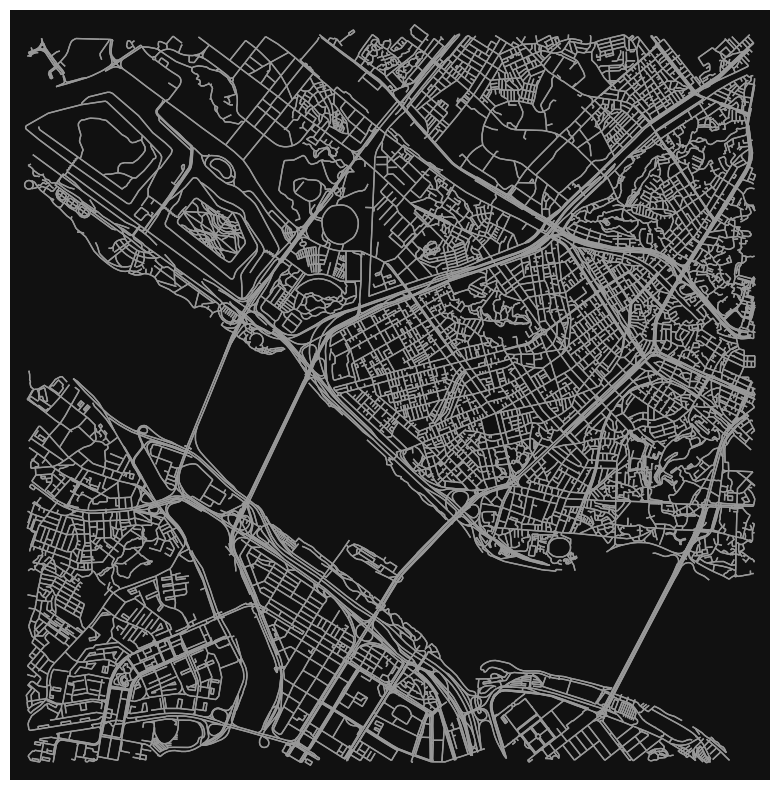

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [21]:
ox.plot_graph(G_big, node_size=0, figsize=(10, 10))

서울 전체 간선 수: 472068


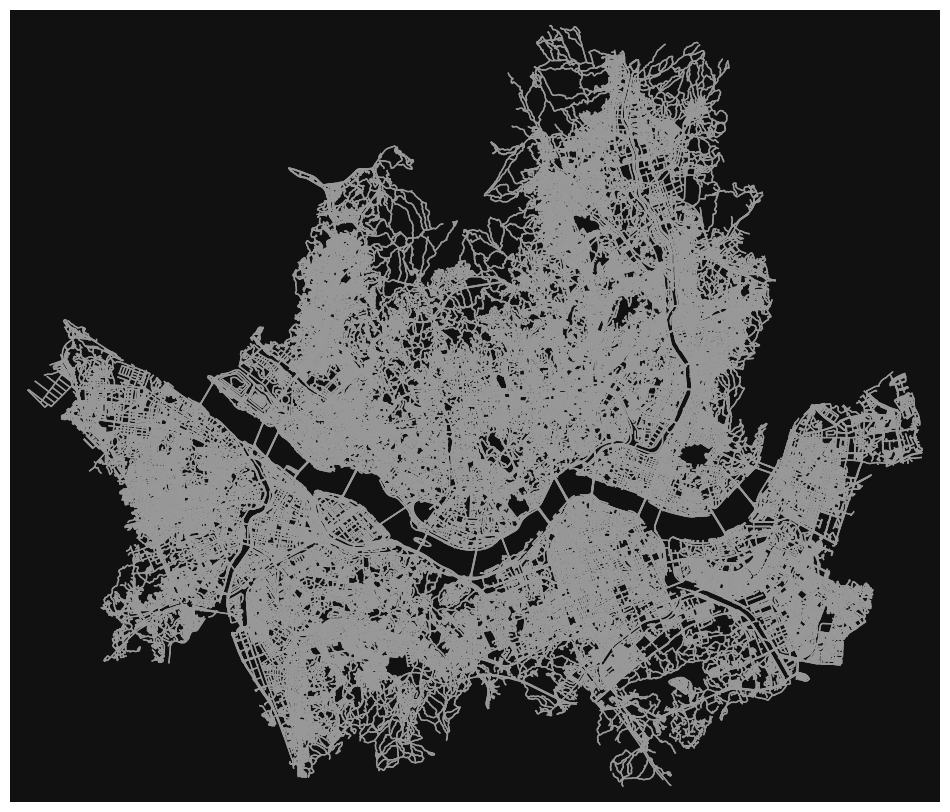

서울 전체 계단 구간 수: 6304


In [3]:
import osmnx as ox
# 서울 전체 도로망 받기 (아직 안 받으셨으면)
G_seoul = ox.graph_from_place("Seoul, South Korea", network_type="walk")
print("서울 전체 간선 수:", G_seoul.number_of_edges())

nodes_seoul, edges_seoul = ox.graph_to_gdfs(G_seoul)

# 1) 전체 도로망 모양은 가벼운 정적 이미지로만 확인
ox.plot_graph(G_seoul, node_size=0, figsize=(12, 12))

# 2) 인터랙티브 지도에는 "계단만" 올리기 (전체 올리면 무거움)
steps_only = edges_seoul[edges_seoul["highway"].apply(
    lambda h: h == "steps" or (isinstance(h, list) and "steps" in h)
)]
print("서울 전체 계단 구간 수:", len(steps_only))

steps_only.explore(color="red", tiles="CartoDB positron")